
# t-SNE krok po kroku: dopasowywanie macierzy podobieństw

> Materiał dydaktyczny inspirowany stylem wyjaśniania StatQuest, ale przykłady, kod i rysunki są przygotowane od zera.

Ten notebook pokazuje dokładnie ten mechanizm, o który chodzi w animacji t-SNE:

1. W oryginalnej przestrzeni liczymy **docelową macierz podobieństw** `P`.
2. W niskim wymiarze, tutaj na osi 1D, liczymy **aktualną macierz podobieństw** `Q`.
3. t-SNE przesuwa punkty małymi krokami tak, żeby `Q` robiła się coraz bardziej podobna do `P`.

Najważniejsza rzecz do obserwacji:

```text
na początku Q jest chaotyczna,
potem punkty przesuwają się na osi,
a Q stopniowo zaczyna mieć takie same bloki jak P.
```

To jest wersja poprawiona względem prostej animacji: tutaj naprawdę liczymy gradient t-SNE i zapisujemy kolejne iteracje optymalizacji.


# Czym jest t-SNE?

Wyobraź sobie, że mamy dane opisane przez wiele cech.

Każdy punkt może mieć:

- 10 cech,
- 100 cech,
- 1000 cech,

przez co nie jesteśmy w stanie ich bezpośrednio narysować.

Celem t-SNE jest umieszczenie tych punktów na płaszczyźnie (2D) lub w przestrzeni (3D) tak, aby punkty podobne pozostały blisko siebie.

Najważniejsza idea:

> t-SNE nie próbuje zachować dokładnych odległości.
>
> t-SNE próbuje zachować sąsiedztwa.

Jeżeli dwa punkty były podobne w oryginalnych danych, algorytm stara się umieścić je blisko siebie również na wykresie.

Jeżeli dwa punkty były bardzo różne, algorytm stara się je rozsunąć.

W efekcie powstaje mapa, na której możemy zobaczyć:

- grupy podobnych obiektów,
- klastry,
- lokalną strukturę danych.

Dlatego t-SNE jest jedną z najpopularniejszych metod wizualizacji danych wysokowymiarowych.

## Jak myśli t-SNE?

t-SNE działa w trzech krokach:

1. Sprawdza, które punkty są do siebie podobne w oryginalnych danych.
2. Tworzy nowy układ punktów w 2D.
3. Przesuwa punkty tak długo, aż sąsiedztwa na wykresie będą przypominały sąsiedztwa w danych.

Można to zapisać schematem:

Dane → podobieństwa → nowy układ punktów → poprawianie układu → wykres

## W tym notebooku użyjemy

✓ Macierzy odległości D

✓ Macierzy podobieństw P

✗ Macierzy kowariancji
✗ Centroidów

## Do jakiej rodziny należy metoda?

PCA:
→ metody projekcyjne

t-SNE:
→ metody podobieństw

UMAP:
→ metody grafowe

KNN:
→ metody sąsiedztwa

DBSCAN:
→ metody gęstościowe

KMeans:
→ metody centroidowe

LDA:
→ metody dyskryminacyjne

SVM:
→ metody maksymalnego marginesu


## 0. Importy

Używamy tylko małych danych, żeby wszystko było policzalne i widoczne.


In [19]:

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import HTML, display

np.set_printoptions(precision=3, suppress=True)



## 1. Małe dane: trzy grupy punktów

Tworzymy 12 punktów w 2D:

```text
4 punkty niebieskie,
4 punkty czerwone,
4 punkty pomarańczowe.
```

Wysokowymiarowa przestrzeń jest tutaj tylko 2D, bo chcemy widzieć, co się dzieje. W prawdziwym t-SNE mogłoby to być 100, 768 albo 4096 wymiarów.


In [20]:

def make_toy_data(seed=4):
    rng = np.random.default_rng(seed)
    n_per = 4
    centers = np.array([[-4, 3], [0, 0], [4, 3]], dtype=float)
    X = np.vstack([
        rng.normal(loc=center, scale=0.35, size=(n_per, 2))
        for center in centers
    ])
    labels = np.array(["blue"] * n_per + ["red"] * n_per + ["orange"] * n_per)
    names = np.array([f"B{i+1}" for i in range(n_per)] +
                     [f"R{i+1}" for i in range(n_per)] +
                     [f"O{i+1}" for i in range(n_per)])
    return X, labels, names

X, labels, names = make_toy_data()
N = len(X)
color_map = {"blue": "#4C78A8", "red": "#E45756", "orange": "#F58518"}
point_colors = [color_map[x] for x in labels]

fig = go.Figure()
for lab in ["blue", "red", "orange"]:
    mask = labels == lab
    fig.add_trace(go.Scatter(
        x=X[mask, 0], y=X[mask, 1], mode="markers+text",
        text=names[mask], textposition="top center",
        marker=dict(size=16, color=color_map[lab], line=dict(width=1, color="black")),
        name=lab
    ))
fig.update_layout(
    title="Dane wejściowe: trzy grupy w przestrzeni oryginalnej",
    width=700, height=480,
    xaxis_title="cecha 1", yaxis_title="cecha 2"
)
fig.show()



## 2. Docelowa macierz podobieństw `P`

Najpierw t-SNE patrzy na odległości w przestrzeni oryginalnej.

Dla punktu `i` liczy podobieństwo do punktu `j` przez gaussowski kernel:

$$
p_{j|i}=\frac{\exp(-\lVert x_i-x_j\rVert^2 / 2\sigma_i^2)}{\sum_{k\neq i}\exp(-\lVert x_i-x_k\rVert^2 / 2\sigma_i^2)}
$$

Każdy punkt ma własne `sigma_i`. Dobieramy je przez parametr **perplexity**.

Intuicja:

```text
perplexity ≈ ile efektywnych sąsiadów ma widzieć punkt.
```

Potem symetryzujemy macierz:

$$
p_{ij}=\frac{p_{j|i}+p_{i|j}}{2N}
$$

To jest `P`: macierz podobieństw, którą t-SNE będzie próbowało odtworzyć w niskim wymiarze.


### Co oznaczają symbole?

Niech:

- $x_i$ – współrzędne punktu $i$ w oryginalnej przestrzeni,
- $d_{ij}$ – odległość między punktami $i$ i $j$,
- $p_{ij}$ – podobieństwo punktów $i$ i $j$ w przestrzeni wejściowej.

W t-SNE nie pracujemy bezpośrednio na współrzędnych punktów. Najpierw zamieniamy odległości na prawdopodobieństwa sąsiedztwa:

- duże $p_{ij}$ → punkty są bardzo podobne,
- małe $p_{ij}$ → punkty są mało podobne.

W efekcie powstaje macierz `P`, która jest celem całej optymalizacji.


### Skąd bierze się macierz $P$?

W oryginalnej przestrzeni danych każdy punkt opisany jest przez wektor cech:

$$
x_i=(x_{i1},x_{i2},...,x_{id})
$$

Najpierw obliczamy odległości euklidesowe między punktami:

$$
d_{ij}=||x_i-x_j||
$$

Następnie zamieniamy te odległości na prawdopodobieństwa sąsiedztwa za pomocą funkcji Gaussa:

$
p_{j|i}
=
\frac{
\exp\left(
-\frac{||x_i-x_j||^2}{2\sigma_i^2}
\right)
}
{
\sum_{k\neq i}
\exp\left(
-\frac{||x_i-x_k||^2}{2\sigma_i^2}
\right)
}
$

Interpretacja:

* mała odległość → duże $p_{ij}$,
* duża odległość → małe $p_{ij}$.

Wartość $p_{ij}$ można interpretować jako prawdopodobieństwo, że punkt $j$ jest sąsiadem punktu $i$ w oryginalnych danych.

Parametr $\sigma_i$ określa lokalną skalę sąsiedztwa wokół punktu $i$ i jest dobierany automatycznie na podstawie parametru *perplexity*.


### Interpretacja wzoru

$$
p_{j|i}
=
\frac{
\exp\left(
-\frac{||x_i-x_j||^2}{2\sigma_i^2}
\right)
}
{
\sum_{k\neq i}
\exp\left(
-\frac{||x_i-x_k||^2}{2\sigma_i^2}
\right)
}
$$

gdzie:

- $||x_i-x_j||$ – odległość między punktami w oryginalnej przestrzeni danych,
- $\sigma_i$ – lokalna skala sąsiedztwa punktu $i$,
- licznik określa podobieństwo wyznaczone przez funkcję Gaussa,
- mianownik normalizuje wartości tak, aby ich suma była równa 1,
- $p_{j|i}$ – prawdopodobieństwo, że punkt $j$ jest sąsiadem punktu $i$.

Interpretacja:

- bliskie punkty mają duże $p_{ij}$,
- dalekie punkty mają małe $p_{ij}$.

Macierz $P$ opisuje więc strukturę sąsiedztwa w oryginalnych danych.

In [21]:

def pairwise_squared_distances(X):
    diff = X[:, None, :] - X[None, :, :]
    return np.sum(diff ** 2, axis=2)

def conditional_probabilities_from_distances(D2, perplexity=3.0, tol=1e-5, max_iter=80):
    # Liczy kierunkowe p_{j|i} z binary search po sigma_i.
    # Używamy entropii w bazie 2, więc perplexity = 2^H.
    N = D2.shape[0]
    P_cond = np.zeros((N, N), dtype=float)
    sigmas = np.zeros(N, dtype=float)
    target_entropy = np.log2(perplexity)

    for i in range(N):
        mask = np.arange(N) != i
        Di = D2[i, mask]
        beta = 1.0  # beta = 1 / (2 sigma^2)
        beta_min, beta_max = -np.inf, np.inf

        for _ in range(max_iter):
            p = np.exp(-Di * beta)
            p_sum = p.sum()
            if p_sum <= 1e-12:
                p = np.ones_like(Di) / len(Di)
            else:
                p = p / p_sum
            H = -(p * np.log2(p + 1e-12)).sum()
            H_diff = H - target_entropy

            if abs(H_diff) < tol:
                break

            # Entropia za duża -> rozkład za szeroki -> zwiększamy beta -> mniejsze sigma.
            if H_diff > 0:
                beta_min = beta
                beta = beta * 2 if np.isinf(beta_max) else (beta + beta_max) / 2
            else:
                beta_max = beta
                beta = beta / 2 if np.isinf(beta_min) else (beta + beta_min) / 2

        P_cond[i, mask] = p
        sigmas[i] = np.sqrt(1.0 / (2.0 * beta))

    return P_cond, sigmas

D2 = pairwise_squared_distances(X)
P_cond, sigmas = conditional_probabilities_from_distances(D2, perplexity=3.0)
P = (P_cond + P_cond.T) / (2 * N)
P = P / P.sum()

pd.DataFrame(P, index=names, columns=names).round(4)


,B1,B2,B3,B4,R1,R2,R3,R4,O1,O2,O3,O4
B1,0.0000,0.0267,0.0300,0.0304,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
B2,0.0267,0.0000,0.0221,0.0274,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
B3,0.0300,0.0221,0.0000,0.0299,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
B4,0.0304,0.0274,0.0299,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
R1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0256,0.0282,0.0285,0.0000,0.0000,0.0000,0.0000
R2,0.0000,0.0000,0.0000,0.0000,0.0256,0.0000,0.0311,0.0286,0.0000,0.0000,0.0000,0.0000
R3,0.0000,0.0000,0.0000,0.0000,0.0282,0.0311,0.0000,0.0246,0.0000,0.0000,0.0000,0.0000
R4,0.0000,0.0000,0.0000,0.0000,0.0285,0.0286,0.0246,0.0000,0.0000,0.0000,0.0000,0.0000
O1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0251,0.0271,0.0252
O2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0251,0.0000,0.0305,0.0296



### Jak czytać `P`?

Ponieważ punkty są posortowane jako:

```text
B1 B2 B3 B4 | R1 R2 R3 R4 | O1 O2 O3 O4
```

macierz `P` powinna mieć trzy jasne bloki na przekątnej. To znaczy:

```text
punkty niebieskie są podobne do niebieskich,
czerwone do czerwonych,
pomarańczowe do pomarańczowych.
```


In [22]:

def scale_for_display(M):
    M = M.copy().astype(float)
    np.fill_diagonal(M, 0)
    maxv = np.max(M)
    return M / maxv if maxv > 0 else M

P_vis = scale_for_display(P)

fig = go.Figure(data=go.Heatmap(
    z=P_vis,
    x=names,
    y=names,
    zmin=0, zmax=1,
    colorscale="Reds",
    colorbar=dict(title="similarity")
))
fig.update_layout(
    title="Docelowa macierz P: podobieństwa w oryginalnej przestrzeni",
    width=600, height=560
)
fig.update_yaxes(autorange="reversed")
fig.show()



## 3. Aktualna macierz `Q` w niskim wymiarze

Teraz udajemy, że punkty leżą na jednej osi 1D.

Na początku ustawiamy je **celowo źle**: kolory są wymieszane.

```text
B1, R1, O1, B2, R2, O2, ...
```

Dzięki temu aktualna macierz `Q` będzie na początku chaotyczna — dokładnie jak na rysunku z t-SNE.

W niskim wymiarze t-SNE używa rozkładu t-Studenta:

$$
q_{ij}=\frac{(1+\lVert y_i-y_j\rVert^2)^{-1}}{\sum_{a\neq b}(1+\lVert y_a-y_b\rVert^2)^{-1}}
$$

Czyli punkty blisko siebie na osi mają duże `q_ij`, a dalekie mają małe `q_ij`.


### Skąd bierze się macierz $Q$?

Po utworzeniu nowego układu punktów

$$
y_1,y_2,\ldots,y_n
$$

(obecnie w 2D lub 3D) ponownie liczymy odległości między punktami.

W klasycznym SNE używano rozkładu Gaussa również w tej przestrzeni. Powodowało to jednak problem zwany *crowding problem*.

Dlatego w t-SNE zastosowano rozkład t-Studenta o jednym stopniu swobody:

$$
t_1(x)=\frac{1}{\pi(1+x^2)}
$$

W praktyce prowadzi to do definicji:

$$
q_{ij}
=
\frac{
(1+||y_i-y_j||^2)^{-1}
}
{
\sum_{k\neq l}
(1+||y_k-y_l||^2)^{-1}
}
$$

Interpretacja:

* mała odległość → duże $q_{ij}$,
* duża odległość → małe $q_{ij}$.

Podobnie jak wcześniej, $q_{ij}$ można interpretować jako prawdopodobieństwo sąsiedztwa, ale już w aktualnym ułożeniu punktów na wykresie.

Rozkład t-Studenta ma znacznie „grubsze ogony” niż rozkład normalny. Dzięki temu dalekie punkty odpychają się słabiej, co pozwala lepiej rozdzielać klastry i ogranicza problem ich sztucznego zagęszczania.


### Interpretacja wzoru

$$
q_{ij}
=
\frac{
(1+||y_i-y_j||^2)^{-1}
}
{
\sum_{k\neq l}
(1+||y_k-y_l||^2)^{-1}
}
$$

gdzie:

- $||y_i-y_j||$ – odległość między punktami $i$ i $j$ na aktualnym wykresie,
- $(1+||y_i-y_j||^2)^{-1}$ – surowe podobieństwo wyznaczone przez rozkład t-Studenta,
- $\sum_{k\neq l}(1+||y_k-y_l||^2)^{-1}$ – suma wszystkich podobieństw (normalizacja),
- $q_{ij}$ – prawdopodobieństwo, że punkty $i$ i $j$ są sąsiadami w aktualnym osadzeniu.

Interpretacja:

- mała odległość $\Rightarrow$ duże $q_{ij}$,
- duża odległość $\Rightarrow$ małe $q_{ij}$.

Innymi słowy, $q_{ij}$ opisuje, jak bardzo punkty są podobne lub bliskie sobie na aktualnym wykresie.

### Co oznacza podobieństwo w t-SNE?

W t-SNE nie porównujemy bezpośrednio współrzędnych punktów ani samych odległości.

Zamiast tego dla każdej pary punktów obliczamy **podobieństwo**, czyli prawdopodobieństwo, że jeden punkt byłby wybrany jako sąsiad drugiego.

Duże podobieństwo oznacza:

* punkty są blisko siebie,
* należą do tego samego lokalnego otoczenia,
* powinny pozostać blisko również po redukcji wymiarowości.

Małe podobieństwo oznacza:

* punkty są daleko od siebie,
* nie są lokalnymi sąsiadami,
* ich wzajemne położenie jest mniej istotne.

Macierz **P** opisuje podobieństwa w oryginalnych danych, natomiast macierz **Q** opisuje podobieństwa w aktualnym ułożeniu punktów na wykresie.

Celem t-SNE jest takie przesuwanie punktów, aby podobieństwa w macierzy **Q** były jak najbardziej zbliżone do podobieństw zapisanych w macierzy **P**.


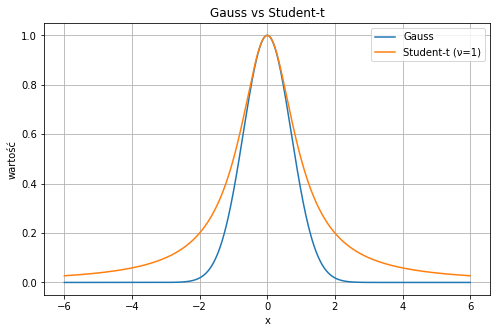

In [23]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 1000)

gauss = np.exp(-x**2)

student = 1/(1 + x**2)

plt.figure(figsize=(8,5))
plt.plot(x, gauss, label="Gauss")
plt.plot(x, student, label="Student-t (ν=1)")
plt.xlabel("x")
plt.ylabel("wartość")
plt.title("Gauss vs Student-t")
plt.legend()
plt.grid(True)

plt.show()

Gauss bardzo szybko zapomina o dalekich punktach.

Student-t zapomina o nich znacznie wolniej.

Dzięki temu dalekie punkty nadal mają niewielki wpływ
na funkcję kosztu.

Pozwala to ograniczyć crowding problem i lepiej
rozdzielać klastry w niskim wymiarze.

In [24]:

def make_bad_initial_1d_positions(N):
    # Kolejność na osi: B1, R1, O1, B2, R2, O2, ...
    interleaved_order = np.array([0, 4, 8, 1, 5, 9, 2, 6, 10, 3, 7, 11])
    y = np.zeros(N, dtype=float)
    y[interleaved_order] = np.linspace(-6, 6, N)
    y = y - y.mean()
    return y

def q_matrix_from_1d(y):
    diff = y[:, None] - y[None, :]
    num = 1.0 / (1.0 + diff ** 2)
    np.fill_diagonal(num, 0.0)
    Q = num / num.sum()
    return Q

y0 = make_bad_initial_1d_positions(N)
Q0 = q_matrix_from_1d(y0)
Q0_vis = scale_for_display(Q0)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["P: docelowa macierz", "Q: aktualna macierz z błędnego 1D"]
)
fig.add_trace(go.Heatmap(z=P_vis, x=names, y=names, zmin=0, zmax=1, colorscale="Reds", showscale=False), row=1, col=1)
fig.add_trace(go.Heatmap(z=Q0_vis, x=names, y=names, zmin=0, zmax=1, colorscale="Reds", showscale=True), row=1, col=2)
fig.update_layout(title="Na początku Q jest chaotyczna, bo punkty w 1D są wymieszane", width=950, height=440)
fig.update_yaxes(autorange="reversed")
fig.show()



## 4. Co t-SNE minimalizuje?

`t-SNE` chce, żeby `Q` była podobna do `P`.

Mierzy różnicę przez dywergencję KL:

$$
KL(P\Vert Q)=\sum_{i,j}p_{ij}\log\frac{p_{ij}}{q_{ij}}
$$

Interpretacja:

```text
jeśli P_ij jest duże, a Q_ij małe → punkty powinny się przyciągać,
jeśli P_ij jest małe, a Q_ij duże → punkty powinny się odpychać.
```

Gradient dla 1D ma postać:

$$
\frac{\partial C}{\partial y_i}
=
4\sum_j (p_{ij}-q_{ij})\frac{(y_i-y_j)}{1+\lVert y_i-y_j\rVert^2}
$$

W notebooku poniżej naprawdę wykonujemy te kroki i zapisujemy kolejne macierze `Q`.


### Znaczenie poszczególnych symboli

Wzór

$$
KL(P\Vert Q)=\sum_{i,j}p_{ij}\log\frac{p_{ij}}{q_{ij}}
$$

zawiera:

- $P$ – macierz podobieństw w oryginalnych danych,
- $Q$ – macierz podobieństw w aktualnym ułożeniu punktów,
- $p_{ij}$ – element macierzy $P$,
- $q_{ij}$ – element macierzy $Q$,
- $KL(P\Vert Q)$ – funkcję kosztu minimalizowaną przez t-SNE.

Im mniejsza wartość KL, tym bardziej aktualne ułożenie punktów przypomina strukturę danych wejściowych.


t-SNE działa jak układ sprężyn.

Jeżeli dwa punkty są bardziej podobne w danych niż na wykresie
($p_{ij}>q_{ij}$), algorytm je przyciąga.

Jeżeli są bardziej podobne na wykresie niż w danych
($p_{ij}<q_{ij}$), algorytm je odpycha.

Optymalizacja kończy się wtedy, gdy macierz podobieństw Q
jak najlepiej przypomina macierz podobieństw P.

### Jak czytać ten wzór?

t-SNE porównuje dwie macierze podobieństw:

- `P` mówi, które punkty są podobne w oryginalnych danych,
- `Q` mówi, które punkty są podobne na aktualnym wykresie.

Algorytm chce, aby `Q` było jak najbardziej podobne do `P`.

Dla każdej pary punktów $(i,j)$ porównujemy:

$$
p_{ij}
\quad \text{oraz} \quad
q_{ij}
$$

czyli pytamy:

> Czy para punktów, która była podobna w danych, nadal jest podobna na wykresie?

---

### Przykład interpretacji

| Sytuacja | Znaczenie | Co zrobi t-SNE? |
|---|---|---|
| $p_{ij}$ duże, $q_{ij}$ małe | Punkty są podobne w danych, ale daleko na wykresie | przyciągnie je |
| $p_{ij}$ małe, $q_{ij}$ duże | Punkty są różne w danych, ale blisko na wykresie | odepchnie je |
| $p_{ij} \approx q_{ij}$ | Wykres dobrze oddaje podobieństwo | prawie nic nie zmieni |

---

### Intuicja

t-SNE można sobie wyobrazić jak układ sprężyn:

- podobne punkty powinny się przyciągać,
- niepodobne punkty powinny się odpychać,
- algorytm przesuwa punkty tak długo, aż układ stanie się możliwie stabilny.

Dlatego gradient zawiera różnicę:

$$
p_{ij} - q_{ij}
$$

To właśnie ta różnica mówi, czy dana para punktów ma się przyciągać, czy odpychać.

### Najważniejsza idea t-SNE

Można podsumować cały algorytm jednym schematem:

```
odległości w danych
        ↓
      Gauss
        ↓
        P

        ≈

        Q
        ↓
   t-Student
        ↓
odległości na wykresie
```

t-SNE nie próbuje zachować samych odległości.

Próbuje zachować podobieństwa sąsiedztwa:

$$
P \approx Q.
$$

Jeżeli dwa punkty są podobne w danych ($p_{ij}$ duże), algorytm stara się umieścić je blisko siebie również na wykresie ($q_{ij}$ duże).



Gauss zachowuje się jak bardzo krótkozasięgowa interakcja.

Student-t zachowuje się jak interakcja o dłuższym zasięgu.

Dzięki temu punkty odległe nadal w niewielkim stopniu wpływają na funkcję kosztu.

Pozwala to rozsunąć klastry i ogranicza problem ich sztucznego zagęszczania (crowding problem).

In [25]:

def kl_divergence(P, Q):
    mask = P > 0
    return float(np.sum(P[mask] * np.log((P[mask] + 1e-12) / (Q[mask] + 1e-12))))

def tsne_gradient_1d(y, P_used, Q):
    diff = y[:, None] - y[None, :]
    inv = 1.0 / (1.0 + diff ** 2)
    grad = 4.0 * np.sum((P_used - Q) * inv * diff, axis=1)
    return grad

def run_toy_tsne_1d(P, y_init, n_iter=200, learning_rate=10.0, momentum=0.5, early_exaggeration=4.0, exaggeration_iters=100, every=5):
    y = y_init.copy().astype(float)
    velocity = np.zeros_like(y)
    states = []

    for it in range(n_iter + 1):
        Q = q_matrix_from_1d(y)
        loss = kl_divergence(P, Q)

        if it % every == 0 or it == n_iter:
            states.append({
                "iteration": it,
                "y": y.copy(),
                "Q": Q.copy(),
                "loss": loss
            })

        if it == n_iter:
            break

        P_used = P * early_exaggeration if it < exaggeration_iters else P
        grad = tsne_gradient_1d(y, P_used, Q)

        if it == exaggeration_iters:
            velocity[:] = 0.0

        velocity = momentum * velocity - learning_rate * grad
        y = y + velocity
        y = y - y.mean()

    return states

states = run_toy_tsne_1d(P, y0)

summary = pd.DataFrame({
    "iteration": [s["iteration"] for s in states],
    "KL(P||Q)": [s["loss"] for s in states]
})
summary.head(), summary.tail()


(   iteration  KL(P||Q)
 0          0  2.513774
 1          5  1.867071
 2         10  1.476083
 3         15  0.577091
 4         20  0.657403,
     iteration  KL(P||Q)
 36        180  0.010865
 37        185  0.010827
 38        190  0.010789
 39        195  0.010752
 40        200  0.010715)


## 5. Najważniejsza animacja: `Q` robi się podobna do `P`

Użyj suwaka pod wykresem.

Obserwuj jednocześnie:

```text
lewa macierz: P, czyli wzór docelowy,
środkowa macierz: Q, czyli aktualne podobieństwa w 1D,
prawa macierz: |P - Q|, czyli błąd wzoru,
dolny wykres: punkty przesuwające się na osi 1D,
loss: KL(P||Q), który zwykle spada.
```

To jest dokładnie idea z rysunku: t-SNE przesuwa punkty tak, aby macierz aktualna wyglądała coraz bardziej jak macierz oryginalna.


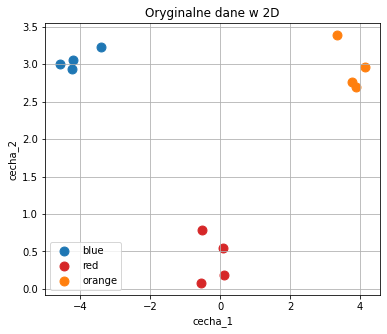

In [26]:
import matplotlib.pyplot as plt

color_map = {
    "blue": "tab:blue",
    "red": "tab:red",
    "orange": "tab:orange"
}

plt.figure(figsize=(6, 5))

for group in ["blue", "red", "orange"]:
    mask = labels == group

    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        label=group,
        color=color_map[group],
        s=80
    )

plt.xlabel("cecha_1")
plt.ylabel("cecha_2")
plt.title("Oryginalne dane w 2D")
plt.legend()
plt.grid(True)

plt.show()

## Co próbujemy osiągnąć?

Powyżej widzimy oryginalne dane opisane przez dwie cechy.

Widzimy trzy naturalne grupy punktów:

- niebieską,
- czerwoną,
- pomarańczową.

Naszym celem będzie zredukowanie danych z 2D do 1D, czyli umieszczenie wszystkich punktów na jednej osi.

Nie chcemy jednak zachować dokładnych współrzędnych punktów.

Chcemy zachować informację o tym:

- które punkty są do siebie podobne,
- które należą do tej samej grupy,
- które powinny pozostać blisko siebie po redukcji wymiarowości.

Innymi słowy:

jeżeli dwa punkty są bliskimi sąsiadami w danych wejściowych, chcielibyśmy, aby pozostały sąsiadami również po przejściu do 1D.

To właśnie będzie próbował osiągnąć algorytm t-SNE.

W kolejnych krokach zobaczymy, jak t-SNE zamienia odległości pomiędzy punktami na podobieństwa, a następnie stopniowo przesuwa punkty na osi 1D tak, aby zachować możliwie dużo informacji o oryginalnej strukturze danych.

In [27]:

# Przygotowanie danych do animacji.
frame_indices = list(range(len(states)))
iterations = np.array([s["iteration"] for s in states])
losses = np.array([s["loss"] for s in states])

# Stałe pionowe przesunięcie tylko po to, żeby punkty nie nachodziły idealnie na siebie.
y_jitter = np.array([0.06, -0.02, 0.025, -0.055] * 3)

P_show = scale_for_display(P)
Q_shows = [scale_for_display(s["Q"]) for s in states]
D_shows = [np.abs(P_show - Qs) for Qs in Q_shows]

# Korelacja wzoru macierzy: pomocnicza miara podobieństwa P i Q dla off-diagonal.
mask_offdiag = ~np.eye(N, dtype=bool)
def matrix_corr(A, B):
    a = A[mask_offdiag].ravel()
    b = B[mask_offdiag].ravel()
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

corrs = np.array([matrix_corr(P_show, Qs) for Qs in Q_shows])

fig = make_subplots(
    rows=2, cols=3,
    row_heights=[0.68, 0.32],
    specs=[
        [{"type": "heatmap"}, {"type": "heatmap"}, {"type": "heatmap"}],
        [{"type": "scatter", "colspan": 2}, None, {"type": "scatter"}],
    ],
    subplot_titles=[
        "P: docelowa macierz z oryginalnej przestrzeni",
        "Q: aktualna macierz z osi 1D",
        "|P - Q|: gdzie jeszcze jest błąd",
        "Aktualne położenie punktów w 1D",
        "KL(P||Q) w czasie",
    ],
    horizontal_spacing=0.08,
    vertical_spacing=0.18,
)

# Trace 0: P target constant.
fig.add_trace(go.Heatmap(
    z=P_show, x=names, y=names, zmin=0, zmax=1,
    colorscale="Reds", showscale=False,
    hovertemplate="P(%{{y}},%{{x}})=%{{z:.2f}}<extra></extra>"
), row=1, col=1)

# Trace 1: Q current.
fig.add_trace(go.Heatmap(
    z=Q_shows[0], x=names, y=names, zmin=0, zmax=1,
    colorscale="Reds", showscale=False,
    hovertemplate="Q(%{{y}},%{{x}})=%{{z:.2f}}<extra></extra>"
), row=1, col=2)

# Trace 2: Difference.
fig.add_trace(go.Heatmap(
    z=D_shows[0], x=names, y=names, zmin=0, zmax=1,
    colorscale="Blues", showscale=True,
    colorbar=dict(title="błąd", len=0.48, y=0.76),
    hovertemplate="|P-Q|=%{{z:.2f}}<extra></extra>"
), row=1, col=3)

# Trace 3: 1D positions.
fig.add_trace(go.Scatter(
    x=states[0]["y"],
    y=y_jitter,
    mode="markers+text",
    text=names,
    textposition="top center",
    marker=dict(size=20, color=point_colors, line=dict(width=1.2, color="black")),
    hovertemplate="punkt=%{{text}}<br>y=%{{x:.2f}}<extra></extra>",
    showlegend=False,
), row=2, col=1)

# Trace 4: line under 1D points.
fig.add_trace(go.Scatter(
    x=[min(states[-1]["y"].min(), states[0]["y"].min()) - 1, max(states[-1]["y"].max(), states[0]["y"].max()) + 1],
    y=[-0.11, -0.11],
    mode="lines",
    line=dict(width=2, color="gray"),
    hoverinfo="skip",
    showlegend=False,
), row=2, col=1)

# Trace 5: full loss curve.
fig.add_trace(go.Scatter(
    x=iterations,
    y=losses,
    mode="lines",
    line=dict(width=2),
    name="KL(P||Q)",
    hovertemplate="iter=%{{x}}<br>KL=%{{y:.4f}}<extra></extra>",
), row=2, col=3)

# Trace 6: moving loss marker.
fig.add_trace(go.Scatter(
    x=[iterations[0]],
    y=[losses[0]],
    mode="markers+text",
    text=[f"iter={{iterations[0]}}, KL={{losses[0]:.3f}}"],
    textposition="top center",
    marker=dict(size=12, color="black"),
    hovertemplate="iter=%{{x}}<br>KL=%{{y:.4f}}<extra></extra>",
    showlegend=False,
), row=2, col=3)

frames = []
for idx, s in enumerate(states):
    frames.append(go.Frame(
        name=str(idx),
        data=[
            go.Heatmap(z=Q_shows[idx]),
            go.Heatmap(z=D_shows[idx]),
            go.Scatter(x=s["y"], y=y_jitter, text=names, marker=dict(size=20, color=point_colors, line=dict(width=1.2, color="black"))),
            go.Scatter(x=[iterations[idx]], y=[losses[idx]], text=[f"iter={{iterations[idx]}}, KL={{losses[idx]:.3f}}, corr={{corrs[idx]:.2f}}"]),
        ],
        traces=[1, 2, 3, 6],
        layout=go.Layout(
            title_text=f"t-SNE jako dopasowywanie macierzy: iteracja {{iterations[idx]}} | KL={{losses[idx]:.4f}} | corr(P,Q)={{corrs[idx]:.3f}}"
        )
    ))

fig.frames = frames

steps = []
for idx, s in enumerate(states):
    steps.append(dict(
        method="animate",
        args=[[str(idx)], dict(mode="immediate", frame=dict(duration=0, redraw=True), transition=dict(duration=0))],
        label=str(s["iteration"])
    ))

fig.update_layout(
    title=f"t-SNE jako dopasowywanie macierzy: iteracja {{iterations[0]}} | KL={{losses[0]:.4f}} | corr(P,Q)={{corrs[0]:.3f}}",
    width=1250,
    height=820,
    margin=dict(l=60, r=30, t=90, b=60),
    sliders=[dict(
        active=0,
        currentvalue=dict(prefix="Iteracja: ", font=dict(size=16)),
        pad=dict(t=45),
        steps=steps
    )],
    updatemenus=[dict(
        type="buttons",
        showactive=False,
        y=0,
        x=0.0,
        xanchor="left",
        yanchor="top",
        pad=dict(t=85, r=10),
        buttons=[
            dict(label="▶ Play", method="animate", args=[None, dict(frame=dict(duration=120, redraw=True), transition=dict(duration=0), fromcurrent=True)]),
            dict(label="⏸ Pause", method="animate", args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")]),
        ]
    )]
)

for axis_name in ["yaxis", "yaxis2", "yaxis3"]:
    fig.layout[axis_name].autorange = "reversed"

fig.update_xaxes(title_text="punkt", row=1, col=1)
fig.update_xaxes(title_text="punkt", row=1, col=2)
fig.update_xaxes(title_text="punkt", row=1, col=3)
fig.update_yaxes(title_text="punkt", row=1, col=1)
fig.update_yaxes(title_text="punkt", row=1, col=2)
fig.update_yaxes(title_text="punkt", row=1, col=3)
fig.update_xaxes(title_text="pozycja na osi 1D", row=2, col=1)
fig.update_yaxes(showticklabels=False, range=[-0.18, 0.18], row=2, col=1)
fig.update_xaxes(title_text="iteracja", row=2, col=3)
fig.update_yaxes(title_text="KL", row=2, col=3)

# Zapis do samodzielnego HTML.
fig.write_html("../html/1_2_tsne_interaktywny_macierz_dopasowania.html", include_plotlyjs=True, full_html=True)

from IPython.display import display, HTML

# Wyświetlenie bezpośrednio w notebooku
display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

# Dodatkowo dla części konfiguracji Jupyter/Plotly
fig.show()


W tym notebooku redukujemy dane z 2D do 1D.

Nie jest to jednak rzutowanie punktów na nową oś (jak w PCA).

Algorytm najpierw oblicza podobieństwa pomiędzy punktami,
a następnie tworzy zupełnie nowe współrzędne w 1D.

Położenia punktów są modyfikowane tak długo,
aż podobieństwa w nowej przestrzeni będą przypominały podobieństwa w danych wejściowych.

### Dlaczego punkty są ułożone jeden nad drugim?

Algorytm t-SNE w tym przykładzie tworzy jednowymiarowe osadzenie.

Każdy punkt posiada więc tylko jedną współrzędną:

$$
y_i
$$

Punkty są lekko przesunięte w pionie wyłącznie dla czytelności wykresu.

Przesunięcie pionowe nie ma żadnego znaczenia matematycznego i nie jest wykorzystywane przez algorytm.

Wszystkie informacje o położeniu punktów znajdują się na osi poziomej.

In [28]:
import pandas as pd

df_points = pd.DataFrame(
    X,
    columns=["cecha_1", "cecha_2"]
)

df_points.insert(0, "punkt", labels)

display(df_points)

,punkt,cecha_1,cecha_2
0,blue,-4.228127,2.938849
1,blue,-3.417697,3.230702
2,blue,-4.574489,2.998179
3,blue,-4.218212,3.052021
4,red,-0.562866,0.084620
5,red,0.082383,0.551469
6,red,0.110826,0.178691
7,red,-0.522591,0.788455
8,orange,3.329524,3.385631
9,orange,3.884534,2.691774


In [29]:
from scipy.spatial.distance import pdist, squareform
import pandas as pd

D = squareform(pdist(X))

df_D = pd.DataFrame(
    D,
    index=labels,
    columns=labels
)

display(df_D.round(2))

,blue,blue,blue,blue,red,red,red,red,orange,orange,orange,orange
blue,0.00,0.86,0.35,0.11,4.65,4.93,5.14,4.28,7.57,8.12,8.00,8.36
blue,0.86,0.00,1.18,0.82,4.25,4.41,4.67,3.79,6.75,7.32,7.20,7.56
blue,0.35,1.18,0.00,0.36,4.96,5.26,5.47,4.62,7.91,8.46,8.35,8.71
blue,0.11,0.82,0.36,0.00,4.71,4.97,5.20,4.33,7.56,8.11,7.99,8.35
red,4.65,4.25,4.96,4.71,0.00,0.80,0.68,0.70,5.10,5.16,5.10,5.51
red,4.93,4.41,5.26,4.97,0.80,0.00,0.37,0.65,4.31,4.36,4.30,4.71
red,5.14,4.67,5.47,5.20,0.68,0.37,0.00,0.88,4.54,4.53,4.48,4.89
red,4.28,3.79,4.62,4.33,0.70,0.65,0.88,0.00,4.65,4.80,4.73,5.14
orange,7.57,6.75,7.91,7.56,5.10,4.31,4.54,4.65,0.00,0.89,0.76,0.91
orange,8.12,7.32,8.46,8.11,5.16,4.36,4.53,4.80,0.89,0.00,0.14,0.37


In [30]:
pairs = []

for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        pairs.append([
            labels[i],
            labels[j],
            D[i, j]
        ])

df_pairs = pd.DataFrame(
    pairs,
    columns=["punkt A", "punkt B", "odległość"]
)

display(
    df_pairs
    .sort_values("odległość")
    .head(10)
)

,punkt A,punkt B,odległość
2,blue,blue,0.113606
63,orange,orange,0.135578
1,blue,blue,0.351407
21,blue,blue,0.360322
64,orange,orange,0.366756
45,red,red,0.373861
65,orange,orange,0.412655
46,red,red,0.649735
39,red,red,0.680228
40,red,red,0.704986


## Jak interpretować animację?

W każdej iteracji algorytm:

1. oblicza aktualną macierz podobieństw Q,
2. porównuje ją z docelową macierzą P,
3. mierzy błąd KL(P||Q),
4. przesuwa punkty,
5. ponownie wyznacza Q.

Celem nie jest bezpośrednie przesuwanie punktów.

Celem jest sprawienie, aby macierz Q była możliwie podobna do macierzy P.

Punkty poruszają się tylko dlatego, że zmiana ich położenia zmienia wartości w macierzy Q.


## 6. Jak interpretować animację?

### Na początku

Punkty na osi 1D są wymieszane:

```text
blue, red, orange, blue, red, orange, ...
```

Dlatego `Q` ma czerwone pola w dziwnych miejscach. To znaczy:

```text
w aktualnym 1D podobne są punkty, które przypadkowo leżą obok siebie,
a niekoniecznie punkty z tej samej grupy.
```

### W trakcie

Gradient t-SNE robi dwa rodzaje ruchu:

```text
jeśli P_ij > Q_ij: punkty i, j za słabo podobne w 1D → przyciągamy je,
jeśli P_ij < Q_ij: punkty i, j za mocno podobne w 1D → odpychamy je.
```

### Pod koniec

Punkty z tych samych grup tworzą osobne skupienia na osi. Wtedy `Q` zaczyna mieć trzy bloki, podobnie jak `P`.

To jest główna intuicja t-SNE:

> t-SNE nie zna klas. t-SNE tylko przesuwa punkty tak, aby macierz podobieństw w małym wymiarze przypominała macierz podobieństw z dużego wymiaru.



## 7. Co warto zapamiętać?

```text
P = podobieństwa w przestrzeni oryginalnej.
Q = podobieństwa w aktualnej przestrzeni 1D/2D.
KL(P||Q) = kara za to, że Q nie wygląda jak P.
Gradient = instrukcja, jak przesunąć punkty, żeby Q bardziej przypominała P.
```

W pełnym t-SNE zwykle używamy 2D, a nie 1D, ale mechanizm jest ten sam.

W następnym notebooku można zrobić analogiczną wersję dla UMAP:

```text
UMAP też ma docelowy graf/macierzą P,
też ma aktualne podobieństwa Q w niskim wymiarze,
ale inaczej buduje P i używa innej funkcji kosztu.
```

Na razie najważniejsze jest zobaczyć t-SNE jako **dopasowywanie macierzy podobieństw przez ruch punktów**.


## Co właściwie robi t-SNE?

t-SNE nie próbuje zachować współrzędnych punktów.

t-SNE nie próbuje zachować odległości.

t-SNE próbuje zachować podobieństwa między punktami.

Cały algorytm można zapisać jako:

dane → P → Q → KL(P||Q) → poprawa Q

gdzie:

- P opisuje podobieństwa punktów w oryginalnej przestrzeni cech,
- Q opisuje podobieństwa tych samych punktów w aktualnym osadzeniu (na wykresie),
- KL mierzy różnicę pomiędzy P i Q.

## Co właściwie porównuje t-SNE?

Pomyślmy o dwóch światach.

### Świat 1: dane oryginalne

Punkty znajdują się w przestrzeni cech:

$$
x_1,x_2,\ldots,x_n
$$

Na ich podstawie tworzymy macierz podobieństw:

$$
P
$$

opisującą, które punkty są lokalnymi sąsiadami.

---

### Świat 2: wykres t-SNE

Punkty mają nowe współrzędne:

$$
y_1,y_2,\ldots,y_n
$$

Na ich podstawie tworzymy macierz:

$$
Q
$$

opisującą sąsiedztwa na wykresie.

---

Celem t-SNE nie jest zachowanie współrzędnych.

Celem t-SNE jest zachowanie relacji sąsiedztwa:

$$
P \approx Q
$$

## Interpretacja sił

Jeżeli:

$$
p_{ij}>q_{ij}
$$

to punkty są bardziej podobne w danych niż na wykresie.

Powinny znaleźć się bliżej siebie.

➡️ przyciąganie

---

Jeżeli:

$$
p_{ij}<q_{ij}
$$

to punkty są bardziej podobne na wykresie niż w danych.

Powinny zostać rozsunięte.

➡️ odpychanie

---

Jeżeli:

$$
p_{ij}\approx q_{ij}
$$

układ jest lokalnie zgodny z danymi.

➡️ prawie brak ruchu

## Co warto zapamiętać?

- t-SNE zachowuje podobieństwa, a nie odległości.

- Macierz P opisuje podobieństwa w danych.

- Macierz Q opisuje podobieństwa na wykresie.

- Funkcja kosztu KL mierzy różnicę między P i Q.

- Student-t pomaga rozwiązać crowding problem.

- Gdy p_ij > q_ij punkty się przyciągają.

- Gdy p_ij < q_ij punkty się odpychają.

## UMAP a t-SNE – podobieństwa i różnice

Na pierwszy rzut oka UMAP i t-SNE często dają podobne wyniki:

- podobne punkty tworzą wspólne klastry,
- różne grupy zostają rozdzielone,
- możliwa jest wizualizacja danych wysokowymiarowych w 2D lub 1D.

Oba algorytmy mają więc podobny cel:

> zachować lokalną strukturę danych po redukcji wymiarowości.

---

### Jak myśli t-SNE?

t-SNE buduje macierz podobieństw:

$$
P
$$

w oryginalnych danych oraz

$$
Q
$$

w aktualnym osadzeniu.

Następnie minimalizuje różnicę pomiędzy nimi:

$$
KL(P||Q)
$$

Można powiedzieć, że t-SNE próbuje odpowiedzieć na pytanie:

> Które punkty są do siebie podobne?

---

### Jak myśli UMAP?

UMAP najpierw buduje graf najbliższych sąsiadów (kNN).

Następnie zamienia go w ważony graf rozmytych połączeń (*fuzzy simplicial set*).

Podczas optymalizacji algorytm stara się zachować te połączenia w nowym układzie punktów.

Można powiedzieć, że UMAP próbuje odpowiedzieć na pytanie:

> Które punkty powinny być ze sobą połączone?

---

### Intuicja

Można myśleć o tych metodach następująco:

| t-SNE | UMAP |
|--------|--------|
| dopasowuje macierze podobieństw | dopasowuje graf sąsiedztwa |
| język prawdopodobieństw | język grafów |
| KL divergence | cross-entropy |
| podobieństwo punktów | połączenia między punktami |
| bardzo silny nacisk na lokalność | lokalność + część struktury globalnej |

---

### Co jest wspólne?

W obu przypadkach punkty są stopniowo przesuwane podczas optymalizacji.

Celem nie jest zachowanie dokładnych współrzędnych punktów, lecz zachowanie informacji o tym:

- kto jest czyim sąsiadem,
- które punkty tworzą wspólne grupy,
- które relacje są najważniejsze w danych.

Dlatego zarówno t-SNE jak i UMAP należą do metod **manifold learning** – próbują odnaleźć ukrytą strukturę danych i zachować ją po redukcji wymiarowości.